# Phase 6 — Regional Cluster Analysis

This notebook adds a regional layer to the municipal typology framework by:

- assigning each municipality to a Puerto Rico region
- analyzing **clusters within regions**
- building a **cluster vs. region** comparison table and heatmap
- checking whether certain regions are **more vulnerable**

## Important note on regions

Puerto Rico is officially divided into **78 municipalities**, not official administrative regions.  
The region framework used here is an **analytical / tourism-style grouping** based on the regional categories presented by Discover Puerto Rico.

For this notebook, we use a **7-region framework**:

- Metro
- North
- South
- West
- East
- Central Mountains
- Culebra & Vieques

If you prefer a 6-region version later, Culebra and Vieques can be merged into **East**.

## 1. Load libraries and Phase 5 outputs

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

analysis_dir = Path(".")
typology_path = analysis_dir / "municipal_typologies_latest_year.csv"
summary_path = analysis_dir / "phase5_typology_summary.json"

if not typology_path.exists():
    raise FileNotFoundError(f"Could not find typology output at: {typology_path}")

df = pd.read_csv(typology_path)

if summary_path.exists():
    with open(summary_path, "r") as f:
        phase5_summary = json.load(f)
    print("Phase 5 summary loaded.")
else:
    phase5_summary = {}
    print("Phase 5 summary file not found. Continuing with typology CSV only.")

print("Regional analysis dataset shape:", df.shape)
df.head()

Phase 5 summary loaded.
Regional analysis dataset shape: (78, 72)


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,per_capita_income_inv,split,vulnerability_index,vulnerability_score_0_1,kmeans_cluster_4,kmeans_cluster_3,hier_cluster_4,hier_cluster_3,typology_label,net_migration_proxy
0,2024,Adjuntas,72001,17960,0,15305,121,7937,313,20.3,...,-9682,test,-0.662450,1.000000,0,1,1,1,Disaster-exposed,NaN
1,2024,Aguada,72003,37758,0,33010,147,17824,465,5.0,...,-13065,test,-2.571220,0.780144,2,1,3,2,Disaster-exposed,NaN
2,2024,Aguadilla,72005,54137,0,46599,158,28777,626,14.8,...,-15387,test,-3.391187,0.685698,0,1,1,1,Disaster-exposed,NaN
3,2024,Aguas Buenas,72007,23614,0,20425,136,10959,307,5.0,...,-15546,test,-3.030436,0.727250,2,1,3,2,Disaster-exposed,NaN
4,2024,Aibonito,72009,24636,0,21516,69,10919,375,6.8,...,-14094,test,-2.818050,0.751713,2,1,3,2,Disaster-exposed,NaN


## 2. Define the municipality-to-region mapping

This mapping uses a 7-region analytical framework based on the tourism/planning-style
regional categories commonly shown by Discover Puerto Rico.

Because region definitions are not official administrative units, this mapping should be treated
as an analytical layer for interpretation rather than a legal or governmental boundary system.

In [2]:
region_map = {
    # Metro
    "San Juan": "Metro",
    "Bayamón": "Metro",
    "Carolina": "Metro",
    "Cataño": "Metro",
    "Guaynabo": "Metro",
    "Toa Alta": "Metro",
    "Toa Baja": "Metro",
    "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North",
    "Barceloneta": "North",
    "Camuy": "North",
    "Dorado": "North",
    "Florida": "North",
    "Hatillo": "North",
    "Manatí": "North",
    "Quebradillas": "North",
    "Vega Alta": "North",
    "Vega Baja": "North",

    # South
    "Arroyo": "South",
    "Coamo": "South",
    "Guayama": "South",
    "Guayanilla": "South",
    "Juana Díaz": "South",
    "Patillas": "South",
    "Peñuelas": "South",
    "Ponce": "South",
    "Salinas": "South",
    "Santa Isabel": "South",
    "Villalba": "South",
    "Yauco": "South",

    # West
    "Aguada": "West",
    "Aguadilla": "West",
    "Añasco": "West",
    "Cabo Rojo": "West",
    "Guánica": "West",
    "Hormigueros": "West",
    "Isabela": "West",
    "Lajas": "West",
    "Las Marías": "West",
    "Maricao": "West",
    "Mayagüez": "West",
    "Moca": "West",
    "Rincón": "West",
    "Sabana Grande": "West",
    "San Germán": "West",
    "San Sebastián": "West",

    # East
    "Canóvanas": "East",
    "Ceiba": "East",
    "Fajardo": "East",
    "Humacao": "East",
    "Juncos": "East",
    "Las Piedras": "East",
    "Loíza": "East",
    "Luquillo": "East",
    "Maunabo": "East",
    "Naguabo": "East",
    "Río Grande": "East",
    "San Lorenzo": "East",
    "Yabucoa": "East",
    "Caguas": "East",
    "Gurabo": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains",
    "Aguas Buenas": "Central Mountains",
    "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains",
    "Cayey": "Central Mountains",
    "Ciales": "Central Mountains",
    "Cidra": "Central Mountains",
    "Comerío": "Central Mountains",
    "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains",
    "Lares": "Central Mountains",
    "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains",
    "Orocovis": "Central Mountains",
    "Utuado": "Central Mountains",

    # Culebra & Vieques
    "Culebra": "Culebra & Vieques",
    "Vieques": "Culebra & Vieques"
}

## 3. Apply the regional mapping and check for unmatched municipalities

In [3]:
if "municipio" not in df.columns:
    raise ValueError("Expected a 'municipio' column in municipal_typologies_latest_year.csv")

df["region"] = df["municipio"].map(region_map)

missing_region = df[df["region"].isna()]["municipio"].tolist()

print("Number of municipalities without a mapped region:", len(missing_region))
missing_region

Number of municipalities without a mapped region: 0


[]

## 4. Region counts

This confirms how many municipalities fall in each analytical region.

In [4]:
region_counts = df["region"].value_counts(dropna=False).sort_index()
region_counts

region
Central Mountains    15
Culebra & Vieques     2
East                 15
Metro                 8
North                10
South                12
West                 16
Name: count, dtype: int64

## 5. Analyze clusters within regions

This section shows how municipal typology clusters are distributed across regions.

In [5]:
# Adjust these names if your final Phase 5 notebook used different cluster column names
cluster_col = None
for candidate in ["kmeans_cluster_3", "kmeans_cluster_4", "kmeans_cluster"]:
    if candidate in df.columns:
        cluster_col = candidate
        break

if cluster_col is None:
    raise ValueError("Could not find a K-means cluster column in the Phase 5 output.")

print("Using cluster column:", cluster_col)

region_cluster_table = pd.crosstab(df["region"], df[cluster_col])
region_cluster_table

Using cluster column: kmeans_cluster_3


kmeans_cluster_3,0,1,2
region,,,
Central Mountains,2,13,0
Culebra & Vieques,1,0,1
East,10,5,0
Metro,8,0,0
North,8,2,0
South,3,9,0
West,0,16,0


In [6]:
region_cluster_share = pd.crosstab(df["region"], df[cluster_col], normalize="index").round(3)
region_cluster_share

kmeans_cluster_3,0,1,2
region,,,
Central Mountains,0.133,0.867,0.0
Culebra & Vieques,0.500,0.000,0.5
East,0.667,0.333,0.0
Metro,1.000,0.000,0.0
North,0.800,0.200,0.0
South,0.250,0.750,0.0
West,0.000,1.000,0.0


## 6. Cluster vs. region heatmap

This heatmap makes it easier to see whether some regions are dominated by certain cluster types.

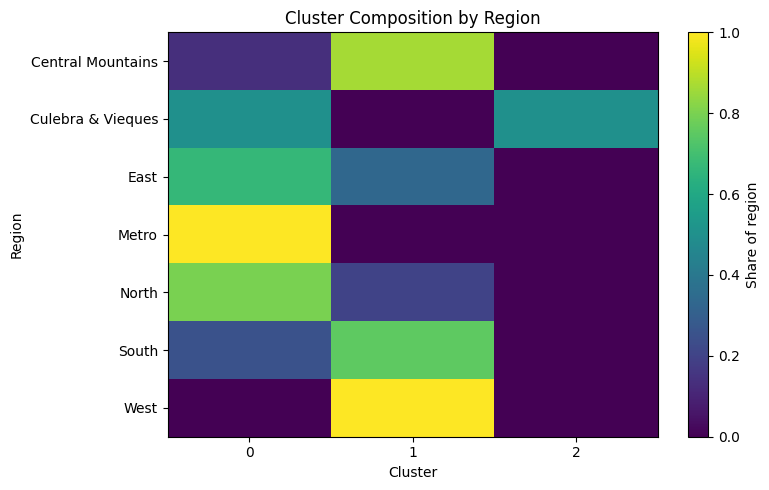

In [7]:
plt.figure(figsize=(8, 5))
plt.imshow(region_cluster_share.values, aspect="auto")
plt.colorbar(label="Share of region")
plt.xticks(range(region_cluster_share.shape[1]), region_cluster_share.columns)
plt.yticks(range(region_cluster_share.shape[0]), region_cluster_share.index)
plt.title("Cluster Composition by Region")
plt.xlabel("Cluster")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 7. Check whether certain regions are more vulnerable

This section compares the 0–1 vulnerability score across regions.

In [8]:
if "vulnerability_score_0_1" not in df.columns:
    raise ValueError("Expected 'vulnerability_score_0_1' from Phase 5 output.")

region_vulnerability = (
    df.groupby("region")["vulnerability_score_0_1"]
    .agg(["mean", "median", "min", "max", "count"])
    .sort_values("mean", ascending=False)
    .round(3)
)

region_vulnerability

,mean,median,min,max,count
region,,,,,
Central Mountains,0.847,0.879,0.585,1.000,15
South,0.799,0.793,0.677,0.990,12
Culebra & Vieques,0.752,0.752,0.525,0.979,2
West,0.751,0.726,0.506,0.995,16
North,0.674,0.696,0.399,0.890,10
East,0.672,0.671,0.445,0.918,15
Metro,0.402,0.398,0.000,0.678,8


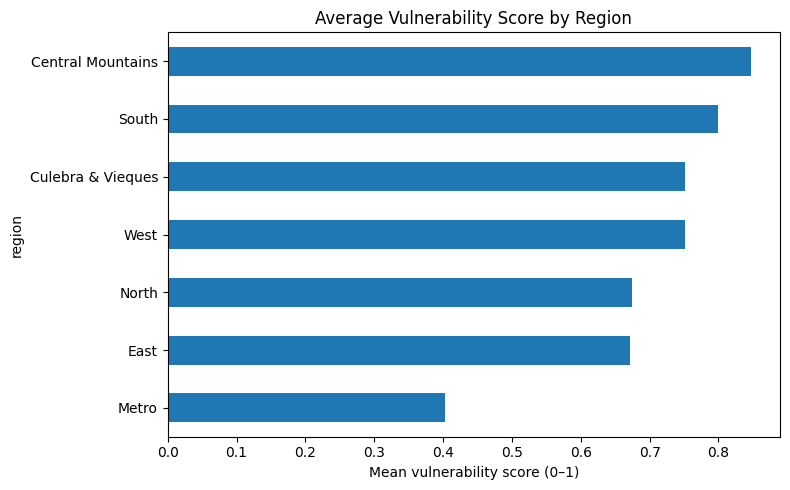

In [9]:
plt.figure(figsize=(8, 5))
region_vulnerability["mean"].sort_values().plot(kind="barh")
plt.title("Average Vulnerability Score by Region")
plt.xlabel("Mean vulnerability score (0–1)")
plt.tight_layout()
plt.show()

## 8. Compare typology labels within regions

This section examines how your final typology labels are distributed by region.

In [10]:
if "typology_label" in df.columns:
    region_typology = pd.crosstab(df["region"], df["typology_label"])
    region_typology
else:
    print("No typology_label column found in Phase 5 output.")

## 9. Identify high-vulnerability municipalities by region

This helps show which municipalities stand out within each region.

In [11]:
top_vulnerable_by_region = (
    df.sort_values(["region", "vulnerability_score_0_1"], ascending=[True, False])
      .groupby("region")
      .head(3)[["region", "municipio", "vulnerability_score_0_1", cluster_col]]
      .reset_index(drop=True)
)

top_vulnerable_by_region

,region,municipio,vulnerability_score_0_1,kmeans_cluster_3
0,Central Mountains,Adjuntas,1.000000,1
1,Central Mountains,Comerío,0.978735,1
2,Central Mountains,Orocovis,0.960029,1
3,Culebra & Vieques,Vieques,0.978506,0
4,Culebra & Vieques,Culebra,0.524953,2
5,East,Maunabo,0.918107,1
6,East,Naguabo,0.829575,0
7,East,Yabucoa,0.809042,1
8,Metro,Cataño,0.678365,0
9,Metro,Toa Alta,0.577980,0


## 10. Optional regional comparison of population momentum

Because lagged population change was an important driver in Phases 2–4, this section compares it across regions.

In [12]:
if "lag_pop_change_1" in df.columns:
    region_momentum = (
        df.groupby("region")["lag_pop_change_1"]
        .agg(["mean", "median", "min", "max"])
        .sort_values("mean", ascending=False)
        .round(3)
    )
    region_momentum
else:
    print("lag_pop_change_1 not found.")

## 11. Export Phase 6 outputs

In [13]:
region_cluster_table_out = analysis_dir / "phase6_region_cluster_counts.csv"
region_cluster_share_out = analysis_dir / "phase6_region_cluster_shares.csv"
region_vulnerability_out = analysis_dir / "phase6_region_vulnerability_summary.csv"
top_vulnerable_out = analysis_dir / "phase6_top_vulnerable_by_region.csv"
summary_out = analysis_dir / "phase6_regional_summary.json"

region_cluster_table.to_csv(region_cluster_table_out)
region_cluster_share.to_csv(region_cluster_share_out)
region_vulnerability.to_csv(region_vulnerability_out)
top_vulnerable_by_region.to_csv(top_vulnerable_out, index=False)

phase6_summary = {
    "cluster_column_used": cluster_col,
    "region_counts": df["region"].value_counts().sort_index().to_dict(),
    "highest_mean_vulnerability_region": region_vulnerability.index[0] if len(region_vulnerability) > 0 else None,
    "missing_region_mappings": missing_region
}

with open(summary_out, "w") as f:
    json.dump(phase6_summary, f, indent=4)

print(f"Saved: {region_cluster_table_out}")
print(f"Saved: {region_cluster_share_out}")
print(f"Saved: {region_vulnerability_out}")
print(f"Saved: {top_vulnerable_out}")
print(f"Saved: {summary_out}")

Saved: phase6_region_cluster_counts.csv
Saved: phase6_region_cluster_shares.csv
Saved: phase6_region_vulnerability_summary.csv
Saved: phase6_top_vulnerable_by_region.csv
Saved: phase6_regional_summary.json


## 12. Interpretation

This notebook adds a regional layer to the municipal typology framework.

It helps answer three questions:

1. **How are clusters distributed across regions?**
2. **Do some regions appear more vulnerable than others?**
3. **Which municipalities stand out within each region?**

In your report, you can frame this phase as a **regional interpretation layer** built on top of the municipal clustering results from Phase 5.